NAIVE BAYES (MY OWN DATASET - digital_mirror_research_dataset_870_rows.csv)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

df = pd.read_csv("digital_mirror_research_dataset_870_rows.csv")

df = df.dropna()

label_encoders = {}

for column in df.columns:
    if df[column].dtype == object:
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

X = df.drop("addiction_risk_level", axis=1)
y = df["addiction_risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical features for MultinomialNB
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_pred_gnb = gnb.predict(X_test)

gnb_accuracy = accuracy_score(y_test, y_pred_gnb)

print("Gaussian Naive Bayes Accuracy:", gnb_accuracy)

print("\nGaussianNB Classification Report:")
print(classification_report(y_test, y_pred_gnb))

mnb = MultinomialNB()

mnb.fit(X_train_scaled, y_train)

y_pred_mnb = mnb.predict(X_test_scaled)

mnb_accuracy = accuracy_score(y_test, y_pred_mnb)

print("\nMultinomial Naive Bayes Accuracy:", mnb_accuracy)

print("\nMultinomialNB Classification Report:")
print(classification_report(y_test, y_pred_mnb))

if gnb_accuracy > mnb_accuracy:
    print("\nGaussianNB performs better.")
elif mnb_accuracy > gnb_accuracy:
    print("\nMultinomialNB performs better.")
else:
    print("\nBoth models perform equally well.")

print("\nSample Predictions:")

for i in range(5):
    print(
        "Actual:", y_test.iloc[i],
        " Predicted (GaussianNB):", y_pred_gnb[i],
        " Predicted (MultinomialNB):", y_pred_mnb[i]
    )

Gaussian Naive Bayes Accuracy: 1.0

GaussianNB Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00        48
           2       1.00      1.00      1.00        64

    accuracy                           1.00       174
   macro avg       1.00      1.00      1.00       174
weighted avg       1.00      1.00      1.00       174


Multinomial Naive Bayes Accuracy: 1.0

MultinomialNB Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00        48
           2       1.00      1.00      1.00        64

    accuracy                           1.00       174
   macro avg       1.00      1.00      1.00       174
weighted avg       1.00      1.00      1.00       174


Both models perform equally well.

Sample Predictions:
Actual: 2  Predicted (GaussianNB): 

KNN CLASSIFICATION (MY OWN DATASET - digital_mirror_research_dataset_870_rows.csv)

Best K Value: 1
Best Cross Validation Score: 0.9094450154162385


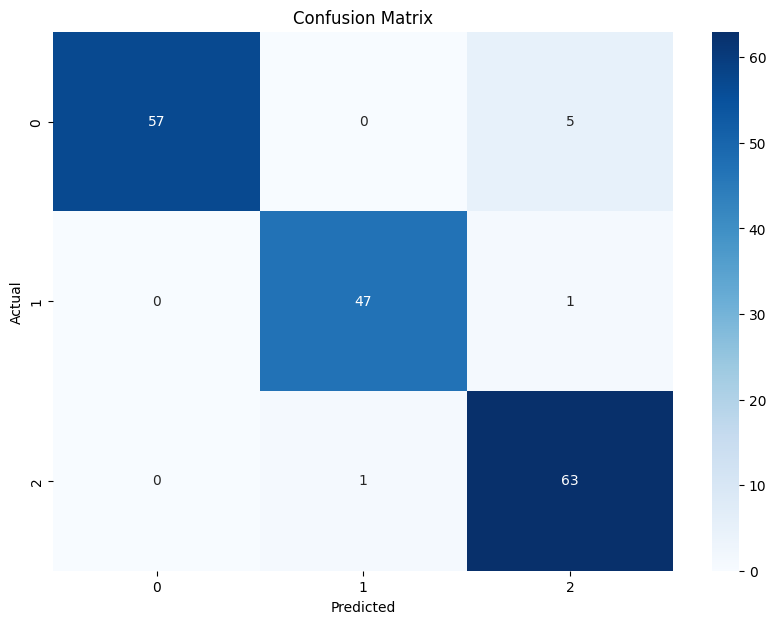

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        62
           1       0.98      0.98      0.98        48
           2       0.91      0.98      0.95        64

    accuracy                           0.96       174
   macro avg       0.96      0.96      0.96       174
weighted avg       0.96      0.96      0.96       174



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("digital_mirror_research_dataset_870_rows.csv")

df = df.dropna()

label_encoders = {}

for column in df.columns:
    if df[column].dtype == object:
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

X = df.drop("addiction_risk_level", axis=1)
y = df["addiction_risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param_grid = {
    'n_neighbors': list(range(1, 21))
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("Best K Value:", grid.best_params_['n_neighbors'])
print("Best Cross Validation Score:", grid.best_score_)

model = grid.best_estimator_

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

report = classification_report(y_test, y_pred)

print("Classification Report:\n")
print(report)

BEST MODEL FOR MY PROBLEM STATEMENT - RANDOM FOREST

(MY OWN DATASET - digital_mirror_research_dataset_870_rows.csv)

  participant_id  age  gender       occupation  daily_usage_hours  \
0          P0001   32   Other          Creator                2.4   
1          P0002   27   Other         Employee                3.9   
2          P0003   33  Female       Freelancer                3.7   
3          P0004   32    Male  College Student               10.1   
4          P0005   25   Other          Creator                1.8   

   night_usage_hours  app_switch_frequency  notification_check_frequency  \
0                1.1                    15                           102   
1                3.8                    20                            58   
2                0.2                    31                            68   
3                0.1                    16                           109   
4                1.0                    15                           141   

   short_video_consumption_rate  average_session_duration  ...  \
0                           6.1                      29.4  ...

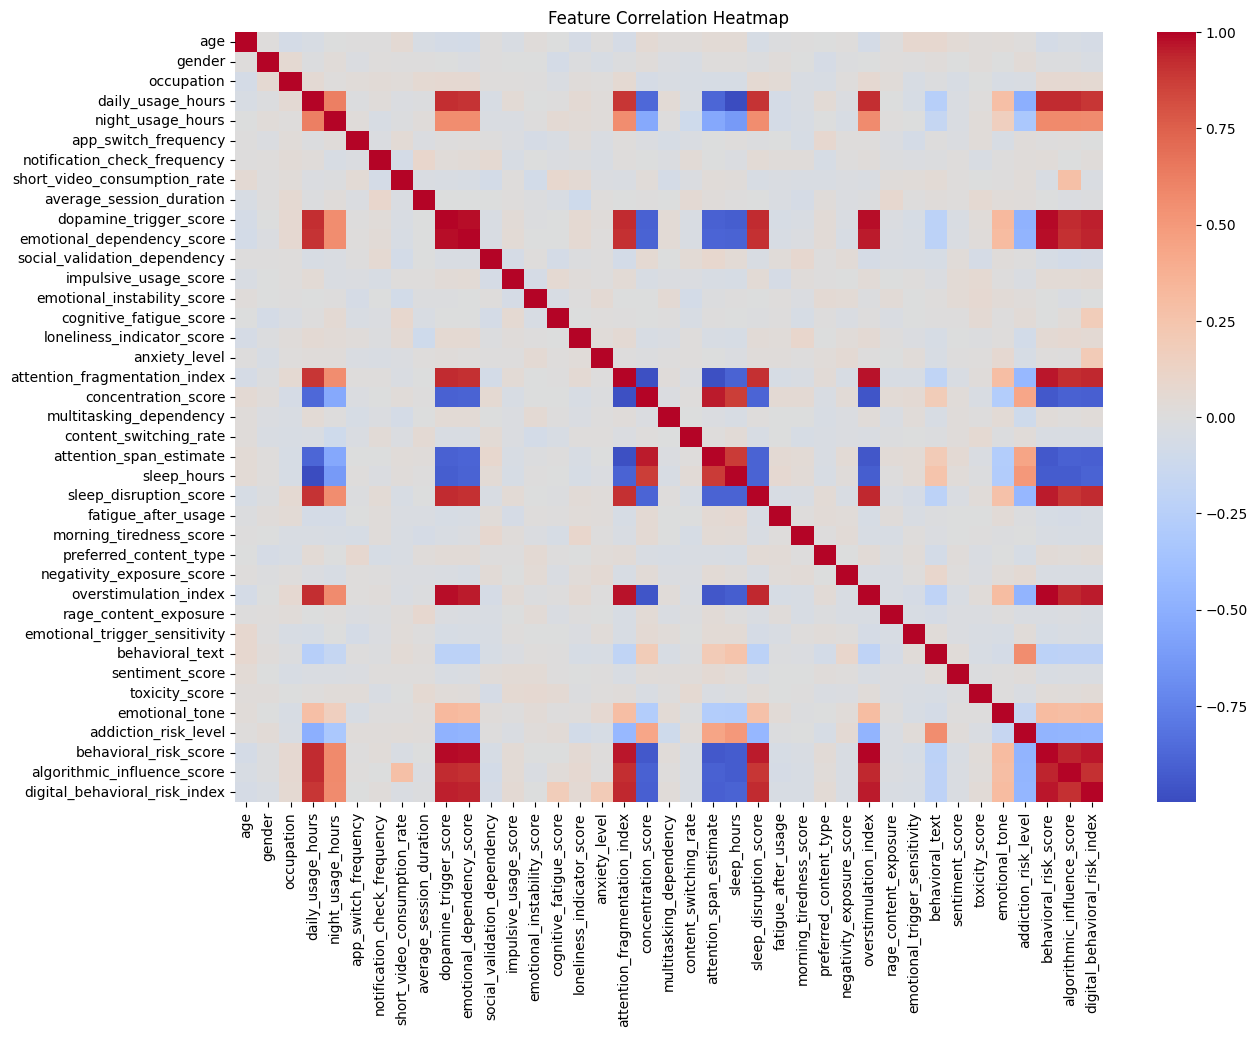

Low Variance Features:
Index([], dtype='object')
Shape After Dimensionality Reduction:
(870, 38)
age : Removed 0 outliers
gender : Removed 0 outliers
occupation : Removed 0 outliers
daily_usage_hours : Removed 0 outliers
night_usage_hours : Removed 1 outliers
app_switch_frequency : Removed 0 outliers
notification_check_frequency : Removed 0 outliers
short_video_consumption_rate : Removed 0 outliers
average_session_duration : Removed 0 outliers
dopamine_trigger_score : Removed 0 outliers
emotional_dependency_score : Removed 0 outliers
social_validation_dependency : Removed 0 outliers
impulsive_usage_score : Removed 0 outliers
emotional_instability_score : Removed 0 outliers
cognitive_fatigue_score : Removed 0 outliers
loneliness_indicator_score : Removed 0 outliers
anxiety_level : Removed 0 outliers
attention_fragmentation_index : Removed 0 outliers
concentration_score : Removed 0 outliers
multitasking_dependency : Removed 0 outliers
content_switching_rate : Removed 0 outliers
attention

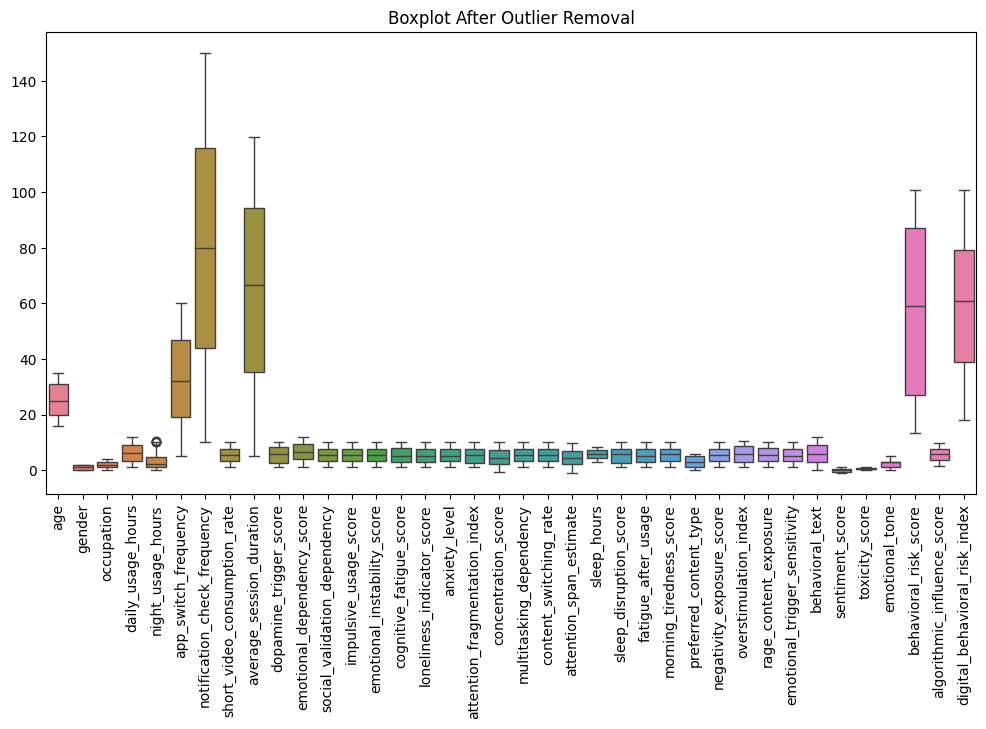

Final Features:
Index(['age', 'gender', 'occupation', 'daily_usage_hours', 'night_usage_hours',
       'app_switch_frequency', 'notification_check_frequency',
       'short_video_consumption_rate', 'average_session_duration',
       'dopamine_trigger_score', 'emotional_dependency_score',
       'social_validation_dependency', 'impulsive_usage_score',
       'emotional_instability_score', 'cognitive_fatigue_score',
       'loneliness_indicator_score', 'anxiety_level',
       'attention_fragmentation_index', 'concentration_score',
       'multitasking_dependency', 'content_switching_rate',
       'attention_span_estimate', 'sleep_hours', 'sleep_disruption_score',
       'fatigue_after_usage', 'morning_tiredness_score',
       'preferred_content_type', 'negativity_exposure_score',
       'overstimulation_index', 'rage_content_exposure',
       'emotional_trigger_sensitivity', 'behavioral_text', 'sentiment_score',
       'toxicity_score', 'emotional_tone', 'behavioral_risk_score',
       '

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("digital_mirror_research_dataset_870_rows.csv")

print(df.head())

print(df.shape)

print(df.columns)

print(df.isnull().sum())

df = df.dropna()

print(df.shape)

df = df.drop('participant_id', axis=1)

label_encoders = {}

for column in df.columns:
    if df[column].dtype == object:
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

print(df.head())

target_column = "addiction_risk_level"

X = df.drop(target_column, axis=1)
y = df[target_column]

print(X.shape)
print(y.shape)

correlation = df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(correlation, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

variance = X.var()

low_variance_features = variance[variance < 0.01].index

print("Low Variance Features:")
print(low_variance_features)

X = X.drop(low_variance_features, axis=1)

print("Shape After Dimensionality Reduction:")
print(X.shape)

numeric_columns = X.select_dtypes(include=np.number).columns

for col in numeric_columns:
    mean = X[col].mean()
    std = X[col].std()

    upper_limit = mean + (3 * std)
    lower_limit = mean - (3 * std)

    before_shape = X.shape[0]

    mask = (X[col] >= lower_limit) & (X[col] <= upper_limit)

    X = X[mask]
    y = y[mask]

    after_shape = X.shape[0]

    print(f"{col} : Removed {before_shape - after_shape} outliers")

print("Final Shape After Outlier Removal:")
print(X.shape)

plt.figure(figsize=(12,6))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.title("Boxplot After Outlier Removal")
plt.show()

X = pd.get_dummies(X, drop_first=True)

print("Final Features:")
print(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print("Test Accuracy:", accuracy)

kfold_accuracy = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print("K Fold Cross Validation Scores:")
print(kfold_accuracy)

print("Average K Fold Accuracy:")
print(kfold_accuracy.mean())

sample_prediction = model.predict(X_test[:5])

print("Sample Predictions:")
print(sample_prediction)

print("Actual Values:")
print(y_test.iloc[:5].values)

with open("digital_mirror_random_forest_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model Exported Successfully")

columns_data = {
    "data_columns": [col.lower() for col in X.columns]
}

with open("columns.json", "w") as file:
    file.write(json.dumps(columns_data))

print("Columns Information Exported Successfully")

## Feature Importance from Random Forest Model

Understanding feature importance can provide insights into which variables are most influential in predicting the addiction risk level. This helps in understanding the underlying factors and potentially simplifying the model or data collection process.

Top 10 Most Important Features:


,Feature,Importance
28,overstimulation_index,0.145288
35,behavioral_risk_score,0.133956
3,daily_usage_hours,0.121042
23,sleep_disruption_score,0.114305
9,dopamine_trigger_score,0.101010
17,attention_fragmentation_index,0.091278
37,digital_behavioral_risk_index,0.056664
22,sleep_hours,0.055036
10,emotional_dependency_score,0.046291
18,concentration_score,0.041636


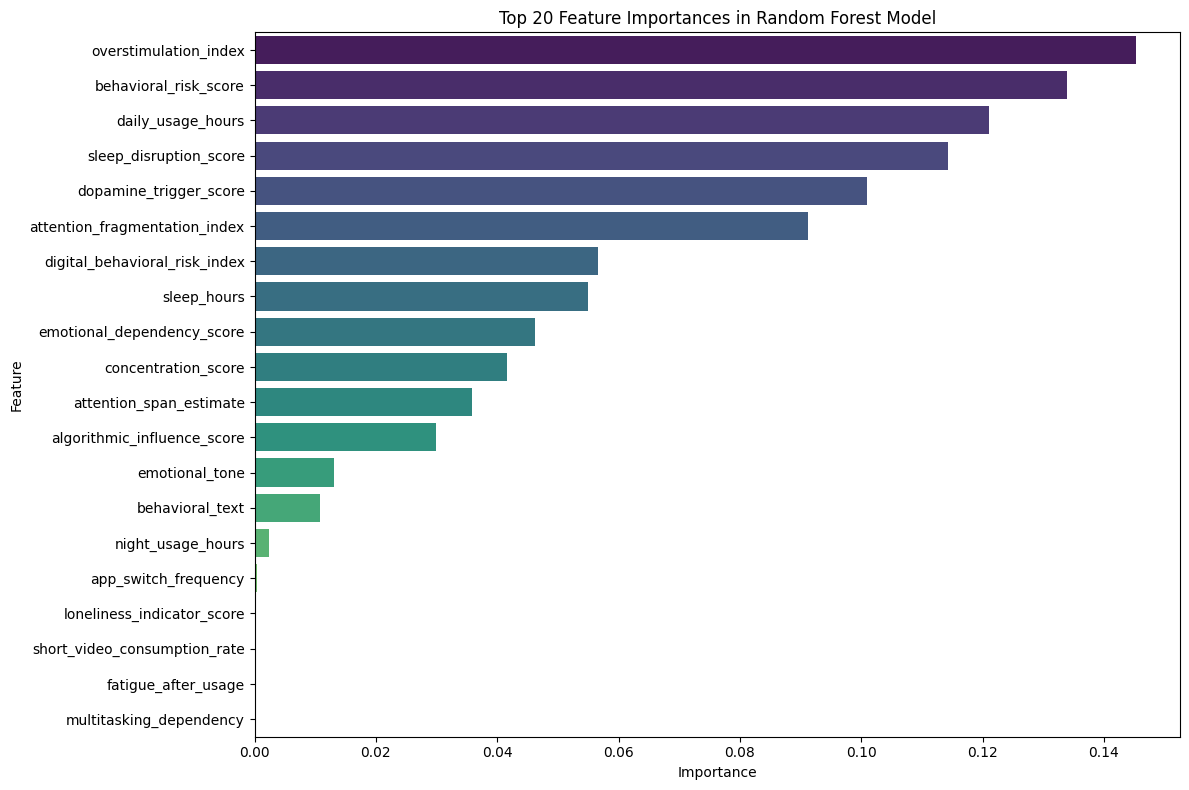

In [14]:
feature_importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features:")
display(importance_df.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis', hue='Feature', legend=False)
plt.title('Top 20 Feature Importances in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Confusion Matrix for Random Forest Model

A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class. This is particularly useful for understanding where the model might be making errors.

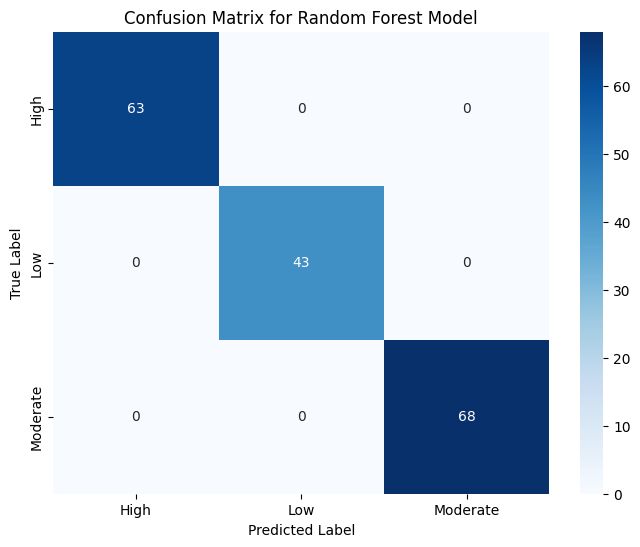

In [15]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoders['addiction_risk_level'].classes_,
            yticklabels=label_encoders['addiction_risk_level'].classes_)
plt.title('Confusion Matrix for Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Predicting Addiction Risk for New Input Data

Now that we have a trained and evaluated model, we can use it to predict the addiction risk level for new, unseen data. This involves loading the saved model and column information, preparing the new input data in the same format as the training data, and then using the model to make predictions.

In [16]:
import pickle
import json
import pandas as pd

with open('digital_mirror_random_forest_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)
with open('columns.json', 'r') as file:
    columns_data = json.load(file)

training_columns = columns_data['data_columns']

print("Model and column information loaded successfully.")

Model and column information loaded successfully.


In [19]:
new_data = {
    'age': [28],
    'gender': ['Male'],
    'occupation': ['Student'],
    'daily_usage_hours': [5.5],
    'night_usage_hours': [2.1],
    'app_switch_frequency': [20],
    'notification_check_frequency': [80],
    'short_video_consumption_rate': [7.0],
    'average_session_duration': [45.0],
    'dopamine_trigger_score': [6.5],
    'emotional_dependency_score': [7.0],
    'social_validation_dependency': [5.0],
    'impulsive_usage_score': [6.0],
    'emotional_instability_score': [5.5],
    'cognitive_fatigue_score': [4.0],
    'loneliness_indicator_score': [3.0],
    'anxiety_level': [4.0],
    'attention_fragmentation_index': [8.0],
    'concentration_score': [6.0],
    'multitasking_dependency': [4.5],
    'content_switching_rate': [3.5],
    'attention_span_estimate': [25.0],
    'sleep_hours': [6.0],
    'sleep_disruption_score': [7.0],
    'fatigue_after_usage': [6.0],
    'morning_tiredness_score': [5.0],
    'preferred_content_type': ['Gaming'],
    'negativity_exposure_score': [6.0],
    'overstimulation_index': [7.5],
    'rage_content_exposure': [5.0],
    'emotional_trigger_sensitivity': [6.0],
    'behavioral_text': ['I feel stressed when I am not online.'],
    'sentiment_score': [0.1],
    'toxicity_score': [0.3],
    'emotional_tone': ['Anxious'],
    'behavioral_risk_score': [70.0],
    'algorithmic_influence_score': [8.0],
    'digital_behavioral_risk_index': [65.0]
}

new_df = pd.DataFrame(new_data)
display(new_df)

,age,gender,occupation,daily_usage_hours,night_usage_hours,app_switch_frequency,notification_check_frequency,short_video_consumption_rate,average_session_duration,dopamine_trigger_score,...,overstimulation_index,rage_content_exposure,emotional_trigger_sensitivity,behavioral_text,sentiment_score,toxicity_score,emotional_tone,behavioral_risk_score,algorithmic_influence_score,digital_behavioral_risk_index
0,28,Male,Student,5.5,2.1,20,80,7.0,45.0,6.5,...,7.5,5.0,6.0,I feel stressed when I am not online.,0.1,0.3,Anxious,70.0,8.0,65.0
